# Board Diversity Beyond the Aggregate

#### Dissertation Analysis Notebook - BUSI 1783 - MSc Business Analytics Project - A Multi-Level Analysis of FTSE 350 Firms, 2019-2024

In [1]:
# Loading necessary libraries for all parts

import re
from itertools import combinations
import hashlib
import datetime as dt
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
import statsmodels.formula.api as smf
from scipy import stats
from sklearn.model_selection import cross_val_score, StratifiedKFold, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

import warnings
warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})

## PART 1

### Data Loading, Cleaning and Anonymisation

In [2]:
# Loading the firm financial dataset and building the six-year firm panel

fin = pd.read_excel("FTSE_350_Firms_Anonymised.xlsx", sheet_name="Results", engine="calamine")
fin = fin[fin["BvD ID number"].notna()].copy()
print("Shape of firm financial dataset:", fin.shape)

# ORBIS stores the six fiscal years side by side; reshaped to a long firm-year panel
YEAR_MAP = {"Last avail. yr": 2024, "Year - 1": 2023, "Year - 2": 2022,
            "Year - 3": 2021, "Year - 4": 2020, "Year - 5": 2019}
VAR_MAP = {"Operating revenue (Turnover) th GBP": "revenue",
           "Total assets th GBP": "assets",
           "Shareholders funds th GBP": "equity",
           "P/L before tax th GBP": "pbt",
           "Non-current liabilities th GBP": "ncl",
           "Number of employees": "employees"}

fin = fin.reset_index(drop=True)
frames = []
for k, (suffix, year) in enumerate(YEAR_MAP.items()):
    part = pd.DataFrame({"bvd": fin["BvD ID number"],
                         "company": fin["Company name Latin alphabet"],
                         "year": year,
                         "sector": fin["NACE Rev. 2 main section"],
                         "country": fin["Country ISO code"]})
    for prefix, name in VAR_MAP.items():
        col = f"{prefix} {suffix}"
        part[name] = fin[col] if col in fin.columns else np.nan
    part["_r"], part["_k"] = fin.index, k
    frames.append(part)
panel = (pd.concat(frames).sort_values(["_r", "_k"], kind="stable")
         .drop(columns=["_r", "_k"]).reset_index(drop=True))

# "n.a." strings coerced to missing
for c in VAR_MAP.values():
    panel[c] = pd.to_numeric(panel[c], errors="coerce")

print("Firm-year panel:", panel["bvd"].nunique(), "firms x 6 years =", len(panel), "rows")
print("\nMissing values per financial variable:")
print(panel[list(VAR_MAP.values())].isnull().sum())


Shape of firm financial dataset: (347, 49)
Firm-year panel: 347 firms x 6 years = 2082 rows

Missing values per financial variable:
revenue      201
assets        42
equity        42
pbt           44
ncl          267
employees    662
dtype: int64


In [3]:
# Loading the anonymised director dataset & pre-processing steps

dirs = pd.read_excel("FTSE_350_Directors_Anonymised.xlsx", sheet_name="Results", engine="calamine")
print("Shape of anonymised director dataset:", dirs.shape)

# Short aliases for the forward-filled identifiers
dirs["company"] = dirs["Company name Latin alphabet"]
dirs["bvd"] = dirs["BvD ID number"]

# Appointment dates arrive as native datetimes and Excel serials
def parse_date(x):
    if pd.isna(x):
        return pd.NaT
    if isinstance(x, (dt.datetime, dt.date, pd.Timestamp)):
        return pd.Timestamp(x)
    try:
        f = float(x)
        if 20000 < f < 60000:
            return pd.Timestamp("1899-12-30") + pd.Timedelta(days=f)
    except (TypeError, ValueError):
        pass
    return pd.NaT

dirs["appt"] = dirs["DMAppointment date"].apply(parse_date)

# Role flags from the ORBIS role codes
roles = dirs["DMType of role"].fillna("")
dirs["is_bod"] = roles.str.contains(r"\bBoD\b")
dirs["is_sen"] = roles.str.contains(r"\bSenMan\b")
dirs["is_aud"] = roles.str.contains(r"\bAudC\b")
dirs["is_rem"] = roles.str.contains(r"\bRemC\b")
dirs["is_nom"] = roles.str.contains(r"\bNomC\b")

dirs["first_nat"] = (dirs["DMCountry/ies of nationality"].fillna("")
                     .str.split(";").str[0].str.strip())
print("Role rows retained after cleaning:", len(dirs))
print("Rows with a parseable appointment date:", dirs["appt"].notna().sum(),
      f"({dirs['appt'].notna().mean():.1%})")


Shape of anonymised director dataset: (15400, 9)
Role rows retained after cleaning: 15400
Rows with a parseable appointment date: 3972 (25.8%)


In [4]:
# Pseudonymous identifiers - verification

# Confirms the pseudonymisation applied by prepare_data.py
assert "DMFull name" not in dirs.columns
print("No name columns present in the working data.")
print("Unique pseudonymous director IDs:", dirs["director_id"].nunique())
dirs[["director_id", "DMGender", "DMAge", "first_nat", "appt"]].head()


No name columns present in the working data.
Unique pseudonymous director IDs: 6350


,director_id,DMGender,DMAge,first_nat,appt
0,c438af0db1b5f92b,M,69.0,United Kingdom,2021-05-18
1,c438af0db1b5f92b,M,69.0,United Kingdom,2020-10-01
2,c438af0db1b5f92b,M,69.0,United Kingdom,NaT
3,c438af0db1b5f92b,M,69.0,United Kingdom,NaT
4,c438af0db1b5f92b,M,69.0,United Kingdom,NaT


In [5]:
# Collapsing role rows into one record per director within each firm

agg = dirs.groupby(["bvd", "company", "director_id"]).agg(
    female=("DMGender", lambda s: (s == "F").any()),
    male=("DMGender", lambda s: (s == "M").any()),
    age=("DMAge", "max"),
    nat=("first_nat", lambda s: next((x for x in s if x), "")),
    appt=("appt", "min"),
    board=("is_bod", "any"), senman=("is_sen", "any"),
    aud=("is_aud", "any"), rem=("is_rem", "any"), nom=("is_nom", "any"),
    n_roles=("DMType of role", "count"),
).reset_index()

# An executive director is defined as holding board AND senior-management roles
agg["exec_"] = agg["board"] & agg["senman"]
agg["gender"] = np.where(agg["female"], "F", np.where(agg["male"], "M", None))

print(len(dirs), "role rows ->", len(agg), "director-firm records")
print("Board seats:", int(agg["board"].sum()),
      "| Executive positions:", int(agg["exec_"].sum()))

# Board seats with no appointment date, retained in every year (Section 3.3)
_bd = agg[agg["board"]]
print(f"Board seats without a recorded appointment date: {_bd['appt'].isna().mean():.1%}")


15400 role rows -> 7373 director-firm records
Board seats: 3432 | Executive positions: 1388
Board seats without a recorded appointment date: 19.9%


### Data Preparation

Two ORBIS exports supply the raw material: firm financials, and one row per director-role. `prepare_data.py` pseudonymised director names before anything else, so no raw export enters this notebook.

The financial file stored six fiscal years side by side; it was reshaped into a long firm-year panel for 2019-2024 and `"n.a."` strings coerced to missing. In the director file, blanked company identifiers were forward-filled, appointment dates parsed from both native datetimes and Excel serials, and role codes split into boolean flags for board membership, senior management and the three monitoring committees.

Each name was normalised, replaced with a salted SHA-256 pseudonym, and the raw column dropped. The salt is held separately. Pseudonyms are deterministic, which the within-firm collapse and cross-firm interlock matching both require.

One limitation enters here and carries throughout: the export covers serving directors only, so reconstructed historical boards omit departures.


## PART 2

### Four-Level Diversity Measures and the Interlock Network

In [6]:
# Constructing the four-level diversity measures per firm-year

# Blau (1977) heterogeneity index: 1 - sum(p_i^2) over category shares
def blau(cats):
    cats = [c for c in cats if c]
    if not cats:
        return np.nan
    p = pd.Series(cats).value_counts(normalize=True)
    return 1 - (p ** 2).sum()

def fem_share(g):
    g = g.dropna(subset=["gender"])
    return np.nan if len(g) == 0 else (g["gender"] == "F").mean()

# Historical boards: director counted in year t if appointed on or before 31 Dec t
div_rows = []
for (bvd, comp), g in agg.groupby(["bvd", "company"]):
    for yr in range(2019, 2025):
        cutoff = pd.Timestamp(f"{yr}-12-31")
        present = g[(g["appt"].isna()) | (g["appt"] <= cutoff)]
        bd_, ex_ = present[present["board"]], present[present["exec_"]]
        rec = {"bvd": bvd, "company": comp, "year": yr,
               "board_size": len(bd_),
               "fem_board": fem_share(bd_),            # Level 1: full board
               "fem_exec": fem_share(ex_),             # Level 2: executive subset
               "blau_nat_board": blau(bd_["nat"]),
               "blau_nat_exec": blau(ex_["nat"]),
               "age_sd_board": bd_["age"].std(),
               "n_exec": len(ex_)}
        shares, blaus = [], []
        for c in ["aud", "rem", "nom"]:                # Level 3: committees
            cm = present[present[c]]
            if len(cm):
                s = fem_share(cm)
                if not np.isnan(s):
                    shares.append(s)
                b = blau(cm["nat"])
                if not np.isnan(b):
                    blaus.append(b)
        rec["fem_comm"] = np.mean(shares) if shares else np.nan
        rec["blau_nat_comm"] = np.mean(blaus) if blaus else np.nan
        rec["has_comm"] = len(shares) > 0
        div_rows.append(rec)
div = pd.DataFrame(div_rows)

print("Diversity panel:", len(div), "firm-years")
print("Committee coverage 2019:", f"{div.loc[div.year == 2019, 'has_comm'].mean():.0%}",
      "-> 2024:", f"{div.loc[div.year == 2024, 'has_comm'].mean():.0%}")


Diversity panel: 2082 firm-years
Committee coverage 2019: 66% -> 2024: 76%


In [7]:
# Building the director interlock network across firms (Level 4)

# Cross-firm identity = pseudonymous ID + age, re-hashed
def rehash(s):
    return hashlib.sha256(("dkey|" + s).encode("utf-8")).hexdigest()[:16]

agg["dkey"] = (agg["director_id"] + "|" +
               agg["age"].fillna(-1).astype(int).astype(str)).apply(rehash)

bd = agg[agg["board"]].copy()
seat_counts = bd.groupby("dkey")["bvd"].nunique()
bd["interlock"] = bd["dkey"].isin(set(seat_counts[seat_counts > 1].index))
print("Unique board directors:", seat_counts.shape[0],
      "| Interlocking (2+ boards):", int((seat_counts > 1).sum()))

G = nx.Graph()
G.add_nodes_from(bd["bvd"].unique())
for _, gg in bd[bd["interlock"]].groupby("dkey"):
    for a, b in combinations(gg["bvd"].unique(), 2):
        G.add_edge(a, b, weight=G.get_edge_data(a, b, {"weight": 0})["weight"] + 1)

giant = max(nx.connected_components(G), key=len)
print("Firms with at least one interlock:",
      sum(1 for n in G if G.degree(n) > 0), "of", G.number_of_nodes())
print(f"Network: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges, "
      f"giant component {len(giant)}, density {nx.density(G):.4f}, "
      f"mean degree {2*G.number_of_edges()/G.number_of_nodes():.2f}")

net = pd.concat([
    pd.Series(dict(G.degree()), name="degree"),
    pd.Series(nx.betweenness_centrality(G), name="betweenness"),
    pd.Series(nx.eigenvector_centrality_numpy(G.subgraph(giant)), name="eigen"),
    bd.groupby("bvd").apply(lambda g: fem_share(g[g["interlock"]]),
                            include_groups=False).rename("fem_inter"),
    bd.groupby("bvd").apply(lambda g: blau(g.loc[g["interlock"], "nat"]),
                            include_groups=False).rename("blau_nat_inter"),
    bd.groupby("bvd")["interlock"].sum().rename("n_interlockers"),
], axis=1).rename_axis("bvd").reset_index()
net["eigen"] = net["eigen"].fillna(0)


Unique board directors: 2852 | Interlocking (2+ boards): 459
Firms with at least one interlock: 310 of 343
Network: 343 nodes, 623 edges, giant component 304, density 0.0106, mean degree 3.63


In [8]:
# Merging financials with diversity measures and deriving analysis variables

df = (panel.merge(div, on=["bvd", "company", "year"], how="inner")
      .merge(net, on="bvd", how="left"))

df["roa"] = df["pbt"] / df["assets"] * 100
df["roe"] = np.where(df["equity"] > 0, df["pbt"] / df["equity"] * 100, np.nan)
df["size"] = np.log(df["assets"].where(df["assets"] > 0))
df["leverage"] = df["ncl"] / df["assets"]

# Winsorised at the 1st/99th percentiles
for c in ["roa", "roe", "leverage"]:
    lo, hi = df[c].quantile([0.01, 0.99])
    df[c + "_w"] = df[c].clip(lo, hi)

df["sector"] = df["sector"].fillna("Unknown").str[:1]

# Deep compliance: >=40% female board AND >=30% female executive subset;
# shallow compliance: the board threshold is met but the executive one is not
df["deep"] = ((df["fem_board"] >= 0.40) & (df["fem_exec"] >= 0.30)).astype(int)
df["shallow"] = ((df["fem_board"] >= 0.40) & (df["fem_exec"] < 0.30)).astype(int)

# Neighbour diversity profile for the diffusion test later
f24 = div[div["year"] == 2024].set_index("bvd")["fem_board"].dropna()
net["nbr_fem"] = net["bvd"].map(
    {n: (np.mean(v) if (v := [f24[m] for m in G.neighbors(n) if m in f24]) else np.nan)
     for n in G})

d24 = df[df["year"] == 2024].copy()
# Excludes four constituents with no board-coded directors -> 343-firm sample
d24 = d24[d24["board_size"] > 0].copy()
print("Merged analysis dataset:", df.shape)
d24[["fem_board", "fem_exec", "fem_comm", "fem_inter", "blau_nat_board",
     "age_sd_board", "board_size", "roa_w", "roe_w", "size",
     "leverage_w"]].describe().round(3).T


Merged analysis dataset: (2082, 36)


,count,mean,std,min,25%,50%,75%,max
fem_board,343.0,0.429,0.121,0.000,0.364,0.429,0.500,0.750
fem_exec,317.0,0.306,0.252,0.000,0.000,0.286,0.444,1.000
fem_comm,262.0,0.518,0.253,0.000,0.389,0.526,0.667,1.000
fem_inter,310.0,0.520,0.317,0.000,0.333,0.500,0.714,1.000
blau_nat_board,343.0,0.319,0.258,0.000,0.000,0.320,0.519,0.864
age_sd_board,339.0,7.191,2.565,0.000,5.602,6.936,8.595,17.587
board_size,343.0,8.837,3.192,1.000,7.000,9.000,11.000,26.000
roa_w,339.0,7.027,9.625,-26.000,1.953,5.932,10.539,48.081
roe_w,334.0,15.799,23.720,-74.275,4.828,11.807,21.688,123.031
size,340.0,14.936,1.746,11.225,13.677,14.639,15.847,21.600


### Measures

The female share and the Blau (1977) nationality index were computed at four levels: the full board (L1), the executive subset defined by joint board and senior-management roles (L2), the average across the audit, remuneration and nomination committees where coded (L3), and the firm's interlocking directors (L4). Committee coverage rises from 66% of firms in 2019 to 76% in 2024. The executive share is coarse where the subset is small: 63 firms have one or two coded executives, and with two, one woman meets the 30% threshold.

A director was attributed to year *t* where the earliest recorded appointment fell on or before 31 December of that year. Two approximations follow and both flatter the early years. Departed directors are invisible in a current-only export and, over a period of rising diversity, disproportionately male. The fifth of board seats without a parseable date were kept in all years, and at 41.6% female carry close to the 2024 composition back into 2019. The documented improvement is therefore conservative.

The interlock network connects firms sharing a board member, matched on pseudonymous identifier plus age. It comprises 343 firms, 623 edges, a giant component of 304 and density 0.011. High-degree nodes were spot-checked for same-age false matches; the network statistics were insensitive.


## PART 3

### Descriptive and Longitudinal Analysis

Mean representation by year and level:
      fem_board  fem_exec  fem_comm  fem_inter  blau_nat_board
year                                                          
2019      0.374     0.253     0.490       0.52           0.238
2020      0.396     0.260     0.492       0.52           0.255
2021      0.404     0.281     0.493       0.52           0.282
2022      0.419     0.283     0.515       0.52           0.293
2023      0.430     0.299     0.528       0.52           0.305
2024      0.429     0.306     0.518       0.52           0.319

Board-executive gap: 2019 12.1pp -> 2024 12.3pp


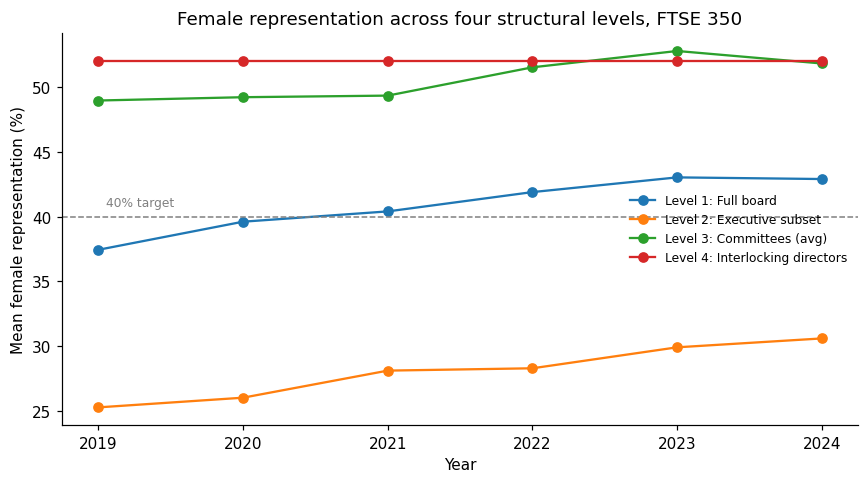

In [9]:
# Tracking female representation at each level across 2019-2024

trend = df.groupby("year")[["fem_board", "fem_exec", "fem_comm", "fem_inter",
                            "blau_nat_board"]].mean()
print("Mean representation by year and level:")
print(trend.round(3))
print("\nBoard-executive gap: 2019 "
      f"{(trend.loc[2019, 'fem_board'] - trend.loc[2019, 'fem_exec'])*100:.1f}pp"
      f" -> 2024 {(trend.loc[2024, 'fem_board'] - trend.loc[2024, 'fem_exec'])*100:.1f}pp")

plt.figure(figsize=(8, 4.5))
for c, lab in [("fem_board", "Level 1: Full board"),
               ("fem_exec", "Level 2: Executive subset"),
               ("fem_comm", "Level 3: Committees (avg)"),
               ("fem_inter", "Level 4: Interlocking directors")]:
    plt.plot(trend.index, trend[c] * 100, marker="o", label=lab)
plt.axhline(40, ls="--", color="grey", lw=1)
plt.text(2019.05, 40.8, "40% target", fontsize=8, color="grey")
plt.ylabel("Mean female representation (%)")
plt.xlabel("Year")
plt.title("Female representation across four structural levels, FTSE 350")
plt.legend(fontsize=8, frameon=False)
plt.tight_layout()
plt.show()

Meet 40% board target: 64.4% of firms
Deep compliers (board >=40% AND exec >=30%): 130 firms (41.0%)
Shallow compliers (board >=40% but exec <30%): 74 firms (23.3%)


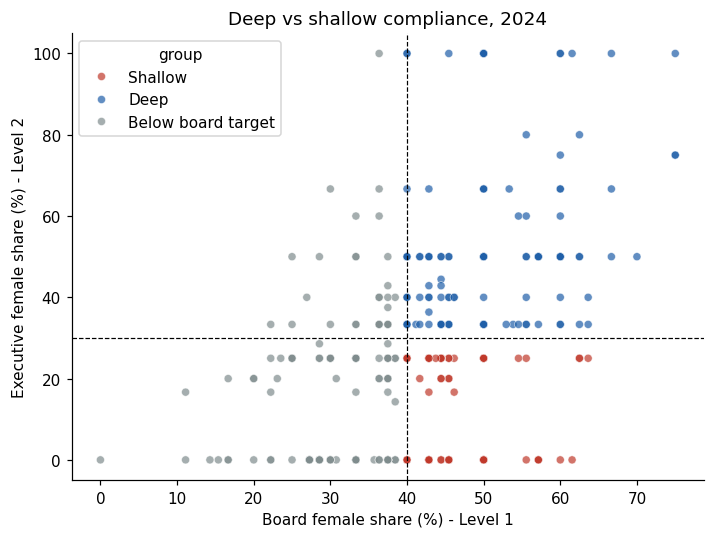


Cross-level correlations (2024):
           fem_board  fem_exec  fem_comm  fem_inter
fem_board       1.00      0.44      0.40       0.23
fem_exec        0.44      1.00      0.08       0.05
fem_comm        0.40      0.08      1.00       0.28
fem_inter       0.23      0.05      0.28       1.00


In [10]:
# Classifying deep vs shallow compliance in 2024

sc = d24.dropna(subset=["fem_board", "fem_exec"])
n_deep = int(((sc["fem_board"] >= .4) & (sc["fem_exec"] >= .3)).sum())
n_shal = int(((sc["fem_board"] >= .4) & (sc["fem_exec"] < .3)).sum())
print(f"Meet 40% board target: {(sc['fem_board'] >= .4).mean():.1%} of firms")
print(f"Deep compliers (board >=40% AND exec >=30%): {n_deep} firms "
      f"({n_deep/len(sc):.1%})")
print(f"Shallow compliers (board >=40% but exec <30%): {n_shal} firms "
      f"({n_shal/len(sc):.1%})")

plt.figure(figsize=(6.6, 5))
sns.scatterplot(data=sc.assign(
    group=np.select([(sc["fem_board"] >= .4) & (sc["fem_exec"] >= .3),
                     (sc["fem_board"] >= .4) & (sc["fem_exec"] < .3)],
                    ["Deep", "Shallow"], default="Below board target")),
    x=sc["fem_board"] * 100, y=sc["fem_exec"] * 100, hue="group",
    palette={"Deep": "#1f5fa8", "Shallow": "#c0392b",
             "Below board target": "#7f8c8d"}, s=28, alpha=.7)
plt.axvline(40, ls="--", color="k", lw=.8)
plt.axhline(30, ls="--", color="k", lw=.8)
plt.xlabel("Board female share (%) - Level 1")
plt.ylabel("Executive female share (%) - Level 2")
plt.title("Deep vs shallow compliance, 2024")
plt.tight_layout()
plt.show()

print("\nCross-level correlations (2024):")
print(d24[["fem_board", "fem_exec", "fem_comm", "fem_inter"]].corr().round(2))

Number of firms per 3pp bin around the target:
  [31%, 34%): 24
  [34%, 37%): 14
  [37%, 40%): 28
  [40%, 43%): 63
  [43%, 46%): 39
  [46%, 49%): 4

Mean change 2021->2024: below-40% firms +10.7pp vs at/above-40% firms -4.1pp
Beta-convergence slope: -0.580 (p=1.78e-71, n=339)


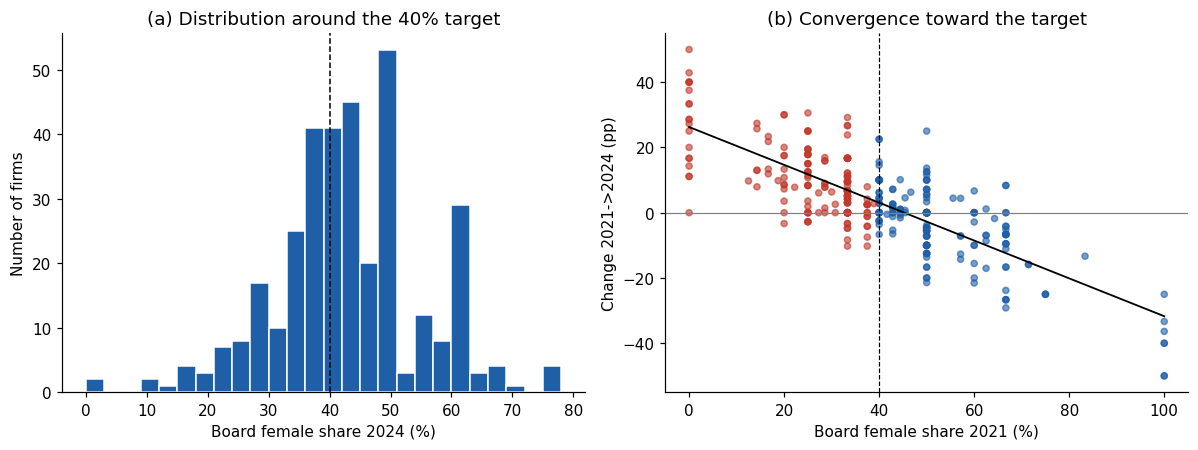

In [11]:
# Examining behaviour around the 40% threshold: bunching and convergence

fb = d24["fem_board"].dropna() * 100
print("Number of firms per 3pp bin around the target:")
for lo in range(31, 47, 3):
    print(f"  [{lo}%, {lo+3}%): {int(((fb >= lo) & (fb < lo+3)).sum())}")

# Change 2021->2024 regressed on the 2021 level
w = div.pivot_table(index="bvd", columns="year", values="fem_board").dropna(
    subset=[2021, 2024])
w["delta"] = w[2024] - w[2021]
w["below40"] = w[2021] < 0.40
print(f"\nMean change 2021->2024: below-40% firms "
      f"{w.loc[w.below40, 'delta'].mean()*100:+.1f}pp vs at/above-40% firms "
      f"{w.loc[~w.below40, 'delta'].mean()*100:+.1f}pp")
conv = smf.ols("delta ~ Q(2021)", data=w.reset_index()).fit()
print(f"Beta-convergence slope: {conv.params.iloc[1]:.3f} "
      f"(p={conv.pvalues.iloc[1]:.2e}, n={len(w)})")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
axes[0].hist(fb, bins=np.arange(0, 80, 3), color="#1f5fa8", edgecolor="white")
axes[0].axvline(40, ls="--", color="k", lw=1)
axes[0].set_xlabel("Board female share 2024 (%)")
axes[0].set_ylabel("Number of firms")
axes[0].set_title("(a) Distribution around the 40% target")
axes[1].scatter(w[2021] * 100, w["delta"] * 100,
                c=np.where(w["below40"], "#c0392b", "#1f5fa8"), s=16, alpha=.6)
xs = np.linspace(w[2021].min() * 100, w[2021].max() * 100, 50)
axes[1].plot(xs, (conv.params.iloc[0] + conv.params.iloc[1] * xs / 100) * 100,
             color="k", lw=1.2)
axes[1].axvline(40, ls="--", color="k", lw=.8)
axes[1].axhline(0, color="grey", lw=.8)
axes[1].set_xlabel("Board female share 2021 (%)")
axes[1].set_ylabel("Change 2021->2024 (pp)")
axes[1].set_title("(b) Convergence toward the target")
plt.tight_layout()
plt.show()


### Descriptive Analysis

Board representation rose from 37.4% in 2019 to 42.9% in 2024, crossing the 40% benchmark in aggregate. The four levels never move together. The executive subset improved almost exactly in parallel (25.3% to 30.6%), so the board-executive gap barely moved, 12.1 to 12.3 percentage points, across the period in which headline compliance surged. Committees sit at or above 49% throughout and interlocking directors are majority-female. Cross-level correlations reach at most 0.44, so no level proxies for another.

The deep/shallow split makes this concrete: 64.4% of firms meet the 40% board target, only 41.0% extend it to at least 30% female executives, and 74 firms (23.3%) comply at the headline level only.

Threshold behaviour splits into two patterns of unequal weight. The 2024 distribution shows excess mass just above 40%: 28 firms in [37%, 40%) against 63 in [40%, 43%). Discreteness on boards of 7 to 11 members predicts clustering at simple fractions, not a step change at one regulatory line, so the bunching is the clearest evidence of a 40% focal point. The convergence regression points elsewhere. A beta-convergence slope of -0.58 implies a steady state of 45.3% (bootstrap 95% CI 43.6 to 47.0), above the target and excluding it: firms below 40% gained +10.7pp, 40-45% +3.5pp, 45-50% -2.1pp and above 50% -13.1pp. Convergence therefore runs toward roughly 45%, equally consistent with regression toward the sample mean, and cannot on its own evidence a 40% magnet. It does show that nothing pulls firms beyond a target-plus-buffer position short of parity.


## PART 4

### Regression Analysis: Diversity and Performance

In [12]:
# Pooled OLS with all four diversity levels entered jointly (firm-clustered SEs)

est = df.dropna(subset=["roa_w", "fem_board", "fem_exec", "size",
                        "leverage_w", "board_size"]).copy()
full = est.dropna(subset=["fem_comm", "fem_inter", "blau_nat_board"])

def cluster_ols(formula, data, label):
    m = smf.ols(formula, data=data).fit(cov_type="cluster",
                                        cov_kwds={"groups": data["bvd"]})
    keep = [t for t in m.params.index if not t.startswith(("C(", "Intercept"))]
    print(f"\n{label} (n={int(m.nobs)}, R2={m.rsquared:.3f})")
    print(pd.DataFrame({"coef": m.params[keep], "se": m.bse[keep],
                        "p": m.pvalues[keep]}).round(3))
    return m

FULL_RHS = ("~ fem_board + fem_exec + fem_comm + fem_inter + blau_nat_board"
            " + size + leverage_w + board_size + C(sector) + C(year)")
m_roa = cluster_ols("roa_w" + FULL_RHS, full, "ROA - all four levels jointly")
m_roe = cluster_ols("roe_w" + FULL_RHS, full.dropna(subset=["roe_w"]),
                    "ROE - all four levels jointly")


ROA - all four levels jointly (n=1059, R2=0.139)
                  coef     se      p
fem_board       14.728  4.839  0.002
fem_exec        -3.503  2.436  0.150
fem_comm        -6.979  2.617  0.008
fem_inter        0.481  2.215  0.828
blau_nat_board  -2.113  2.379  0.374
size            -1.064  0.669  0.112
leverage_w      -8.121  4.153  0.051
board_size       0.161  0.162  0.320

ROE - all four levels jointly (n=1042, R2=0.108)
                  coef      se      p
fem_board       24.691  11.345  0.030
fem_exec        -8.571   5.485  0.118
fem_comm       -14.292   6.614  0.031
fem_inter        2.608   4.998  0.602
blau_nat_board   1.649   5.883  0.779
size            -0.225   1.869  0.904
leverage_w     -16.602  12.310  0.177
board_size       0.165   0.412  0.688


In [13]:
# Robustness: level-by-level models, firm fixed effects & critical mass

print("ROA with one diversity level at a time (same controls):")
for v in ["fem_board", "fem_exec", "fem_comm", "fem_inter", "blau_nat_board"]:
    sub = est.dropna(subset=[v])
    m = smf.ols(f"roa_w ~ {v} + size + leverage_w + board_size + C(sector) + C(year)",
                data=sub).fit(cov_type="cluster", cov_kwds={"groups": sub["bvd"]})
    print(f"  {v:16s} coef={m.params[v]:7.3f}  p={m.pvalues[v]:.3f}  n={int(m.nobs)}")

# Firm fixed effects: within-firm change only
fe = smf.ols("roa_w ~ fem_board + fem_exec + size + leverage_w + board_size"
             " + C(year) + C(bvd)", data=est
             ).fit(cov_type="cluster", cov_kwds={"groups": est["bvd"]})
print(f"\nFirm fixed effects: fem_board {fe.params['fem_board']:.3f} "
      f"(p={fe.pvalues['fem_board']:.3f}); fem_exec {fe.params['fem_exec']:.3f} "
      f"(p={fe.pvalues['fem_exec']:.3f})")

# Critical mass: count of women grouped 0 / 1 / 2 / 3+ rather than a linear share
est["n_women"] = (est["fem_board"] * est["board_size"]).round()
est["cm"] = pd.cut(est["n_women"], [-1, 0, 1, 2, 1000],
                   labels=["0", "1", "2", "3+"])
mcm = smf.ols("roa_w ~ C(cm) + size + leverage_w + board_size + C(sector) + C(year)",
              data=est).fit(cov_type="cluster", cov_kwds={"groups": est["bvd"]})
print("\nCritical mass categories (reference = no women on board):")
for t in ["C(cm)[T.1]", "C(cm)[T.2]", "C(cm)[T.3+]"]:
    print(f"  {t}: coef={mcm.params[t]:6.3f}  p={mcm.pvalues[t]:.3f}")

# Deep vs shallow compliers, 2024
a = d24.loc[d24["deep"] == 1, "roa_w"].dropna()
b = d24.loc[d24["shallow"] == 1, "roa_w"].dropna()
t, p = stats.ttest_ind(a, b, equal_var=False)
print(f"\nDeep (n={len(a)}, mean ROA {a.mean():.2f}) vs shallow (n={len(b)}, "
      f"mean {b.mean():.2f}): Welch t={t:.2f}, p={p:.3f}")


ROA with one diversity level at a time (same controls):
  fem_board        coef=  2.991  p=0.248  n=1558
  fem_exec         coef= -1.261  p=0.409  n=1558
  fem_comm         coef= -3.028  p=0.142  n=1162
  fem_inter        coef= -1.133  p=0.541  n=1421
  blau_nat_board   coef= -1.283  p=0.583  n=1558

Firm fixed effects: fem_board -0.283 (p=0.944); fem_exec 2.898 (p=0.287)

Critical mass categories (reference = no women on board):
  C(cm)[T.1]: coef=-0.264  p=0.892
  C(cm)[T.2]: coef= 2.196  p=0.274
  C(cm)[T.3+]: coef= 3.664  p=0.111

Deep (n=130, mean ROA 6.52) vs shallow (n=72, mean 7.03): Welch t=-0.34, p=0.733



Firm fixed effects: fem_board -0.283 (p=0.944); fem_exec 2.898 (p=0.287)

Critical mass categories (reference = no women on board):
  C(cm)[T.1]: coef=-0.264  p=0.892
  C(cm)[T.2]: coef= 2.196  p=0.274
  C(cm)[T.3+]: coef= 3.664  p=0.111

Deep (n=130, mean ROA 6.52) vs shallow (n=72, mean 7.03): Welch t=-0.34, p=0.733


### Regression Analysis

The joint pooled model looks dramatic: board female share carries +14.7 on ROA (p = 0.002) while committee share carries -7.0 (p = 0.008), with similar signs for ROE. Four checks explain the contradiction.

Entered separately with identical controls, every coefficient collapses (board share +2.99, p = 0.248), so the opposing signs exist only when correlated levels condition on one another. Firm fixed effects remove what remains (board share -0.28, p = 0.944). The critical-mass specification gives the non-linear form its own test: coefficients rise monotonically from one woman (-0.26) to three or more (+3.66), matching Kanter's tokenism argument in shape, but even the 3+ category misses significance (p = 0.111). Deep and shallow compliers show virtually identical mean ROA (6.5 vs 7.0, p = 0.733).

These checks are not independent trials and a weak true effect would fail them together. Each removes a different alternative explanation, and the joint coefficients survive none.


## PART 5

### Director-Level Role Allocation

In [14]:
# Logistic models of who holds which role (gender, nationality, intersection)

d = agg[agg["board"]].dropna(subset=["gender"]).copy()
d["female"] = (d["gender"] == "F").astype(int)
d["nonuk"] = (~d["nat"].isin(["United Kingdom", ""]) & d["nat"].notna()).astype(int)
d["age_c"] = d["age"] - d["age"].mean()
d["any_comm"] = d[["aud", "rem", "nom"]].any(axis=1).astype(int)
d["n_comm"] = d[["aud", "rem", "nom"]].sum(axis=1)
d["multi_comm"] = (d["n_comm"] >= 2).astype(int)
d["exec01"] = d["exec_"].astype(int)
d["bsize"] = d.groupby("bvd")["director_id"].transform("count")
print(f"Sample: {len(d)} board directors | female {d['female'].mean():.1%} | "
      f"non-UK {d['nonuk'].mean():.1%}")

for dv, extra, label in [("exec01", "", "P(executive role)"),
                         ("any_comm", " + exec01", "P(any monitoring committee)"),
                         ("multi_comm", "", "P(2+ committee seats)")]:
    m = smf.logit(f"{dv} ~ female + nonuk + age_c + bsize{extra}",
                  data=d.dropna(subset=["age_c"])).fit(disp=0)
    ci = np.exp(m.conf_int())
    print(f"\n{label} - odds ratios with 95% CI:")
    print(pd.DataFrame({"OR": np.exp(m.params), "CI low": ci[0],
                        "CI high": ci[1], "p": m.pvalues}).round(3))

# Intersectionality: gender x nationality interaction
mi = smf.logit("exec01 ~ female * nonuk + age_c + bsize",
               data=d.dropna(subset=["age_c"])).fit(disp=0)
print("\nInteraction model - female x non-UK:")
print(pd.DataFrame({"OR": np.exp(mi.params), "p": mi.pvalues}).round(3))
print(f"\nNon-UK share of board seats: {d['nonuk'].mean():.1%}"
      f" | of executive positions: {d.loc[d['exec01'] == 1, 'nonuk'].mean():.1%}")
print("\nRaw executive-role rates by group:")
for f in (0, 1):
    for n in (0, 1):
        m_ = d[(d.female == f) & (d.nonuk == n)]
        print(f"  {'female' if f else 'male':6s} x {'non-UK' if n else 'UK':6s}: "
              f"{m_['exec01'].mean():.1%}  (n={len(m_)})")


Sample: 3410 board directors | female 42.6% | non-UK 28.3%

P(executive role) - odds ratios with 95% CI:
              OR  CI low  CI high    p
Intercept  2.162   1.681    2.782  0.0
female     0.414   0.356    0.482  0.0
nonuk      0.674   0.569    0.798  0.0
age_c      0.960   0.951    0.970  0.0
bsize      0.948   0.928    0.969  0.0

P(any monitoring committee) - odds ratios with 95% CI:
              OR  CI low  CI high      p
Intercept  0.838   0.641    1.096  0.197
female     1.726   1.477    2.017  0.000
nonuk      0.844   0.710    1.003  0.055
age_c      1.045   1.034    1.056  0.000
bsize      0.993   0.972    1.015  0.536
exec01     0.349   0.297    0.410  0.000

P(2+ committee seats) - odds ratios with 95% CI:
              OR  CI low  CI high      p
Intercept  0.258   0.194    0.343  0.000
female     2.054   1.733    2.433  0.000
nonuk      0.846   0.697    1.026  0.089
age_c      1.041   1.029    1.053  0.000
bsize      0.988   0.965    1.012  0.340

Interaction model - f

In [15]:
# Appointment cohorts, tenure by gender and the nomination-committee gate

d2 = d.dropna(subset=["appt"]).copy()
d2["cohort"] = pd.cut(d2["appt"].dt.year, [0, 2015, 2019, 2021, 2026],
                      labels=["pre-2016", "2016-19", "2020-21", "2022-24"])
print("Female / non-UK share of appointments by cohort "
      "(currently serving directors only):")
print(d2.groupby("cohort")[["female", "nonuk"]].mean().round(3))

d2["tenure"] = (pd.Timestamp("2024-12-31") - d2["appt"]).dt.days / 365.25
print("\nBoard tenure (years):")
print(d2.groupby("female")["tenure"].agg(["mean", "median", "count"]).round(2)
      .rename(index={0: "male", 1: "female"}))

# Nomination-committee mix in 2021 against the 2022-24 appointment mix
rows_g = []
for bvd_, g in agg.groupby("bvd"):
    cutoff = pd.Timestamp("2021-12-31")
    pres = g[(g["appt"].isna()) | (g["appt"] <= cutoff)]
    nomc = pres[pres["nom"]]
    fnom = fem_share(nomc) if len(nomc) else np.nan
    newap = g[(g["appt"] > cutoff) & g["board"]].dropna(subset=["gender"])
    fnew = (newap["gender"] == "F").mean() if len(newap) >= 2 else np.nan
    rows_g.append({"fem_nom21": fnom, "fem_newappt": fnew})
gate = pd.DataFrame(rows_g).dropna()
r_gate = gate["fem_nom21"].corr(gate["fem_newappt"])
mg = smf.ols("fem_newappt ~ fem_nom21", data=gate).fit()
print(f"\nGatekeeper test (n={len(gate)} firms with 2+ new appointments): "
      f"corr = {r_gate:.3f}, slope = {mg.params['fem_nom21']:.3f} "
      f"(p = {mg.pvalues['fem_nom21']:.3f})")


Female / non-UK share of appointments by cohort (currently serving directors only):
          female  nonuk
cohort                 
pre-2016   0.086  0.238
2016-19    0.417  0.240
2020-21    0.456  0.267
2022-24    0.468  0.291

Board tenure (years):
        mean  median  count
female                     
male    4.39    3.33   1567
female  2.99    2.67   1174

Gatekeeper test (n=173 firms with 2+ new appointments): corr = -0.096, slope = -0.071 (p = 0.211)



Gatekeeper test (n=173 firms with 2+ new appointments): corr = -0.096, slope = -0.071 (p = 0.211)


### Role Allocation

Conditional on age and board size, female directors face odds of holding an executive role only 0.41 times those of male directors, while their odds of sitting on a monitoring committee are 1.73 times higher and of holding two or more committee seats 2.05 times higher (all p < 0.001). Women's presence is channelled into the monitoring architecture rather than operational authority.

Nationality shows the same executive filter (OR 0.67): non-UK directors hold 23.1% of executive positions against 28.3% of board seats. The female x non-UK interaction is not significant (OR 0.90, p = 0.56), so the penalties operate independently on the odds scale. Independent filters still multiply, and non-UK women hold executive roles at 23.3% against 51.4% for UK men, the widest gap in the data.

The pipeline is transforming: among surviving directors the female share of appointments rises from 8.6% (pre-2016) to 46.8% (2022-24), and female tenure averages 3.0 years against 4.4 for men. The gatekeeper test returns a null: nomination-committee gender mix in 2021 does not predict the gender mix of 2022-24 appointments (r = -0.10, p = 0.21). Two readings survive, that diversification is a field-wide shift rather than a firm-level transmission, or that committee composition is a poor proxy for gatekeeping.


## PART 6

### Interlock Network Analysis

Female share among interlocking directors: 51.7% vs 38.6% among single-board directors


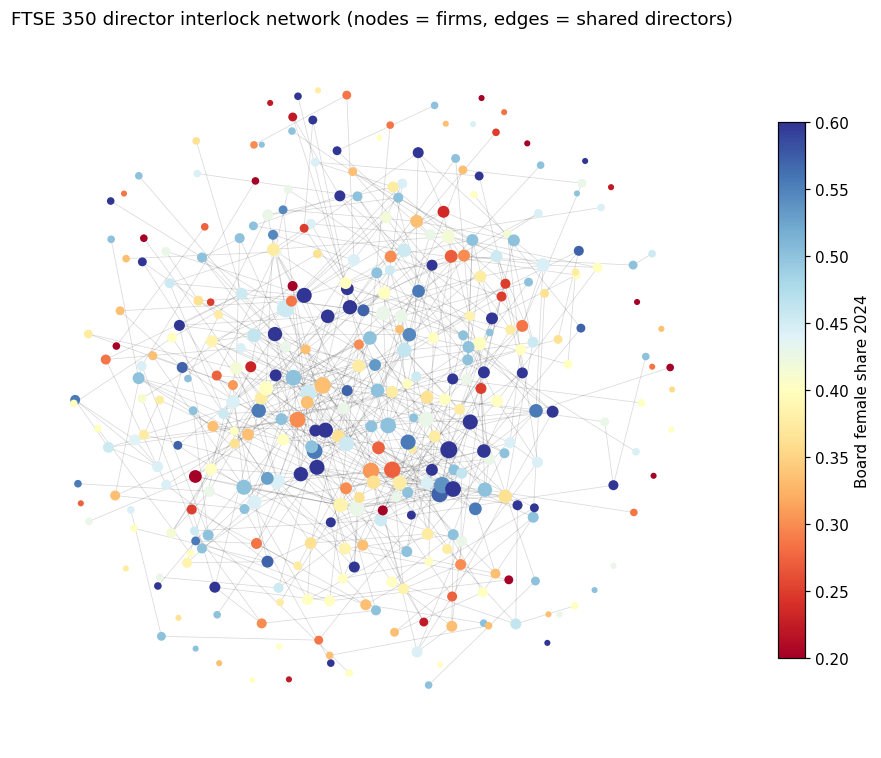

In [16]:
# Visualising the interlock network and the composition of the multi-board elite

gk = bd.dropna(subset=["gender"])
print(f"Female share among interlocking directors: "
      f"{(gk.loc[gk['interlock'], 'gender'] == 'F').mean():.1%} vs "
      f"{(gk.loc[~gk['interlock'], 'gender'] == 'F').mean():.1%} "
      f"among single-board directors")

pos = nx.spring_layout(G, seed=42, k=0.35)
node_col = [f24.get(n, np.nan) for n in G.nodes()]
node_col = [0.4 if np.isnan(v) else v for v in node_col]
deg = dict(G.degree())
plt.figure(figsize=(8.5, 7))
nx.draw_networkx_edges(G, pos, alpha=0.15, width=0.5)
nodes = nx.draw_networkx_nodes(G, pos, node_size=[16 + 9 * deg[n] for n in G],
                               node_color=node_col, cmap="RdYlBu",
                               vmin=0.2, vmax=0.6, linewidths=0)
plt.colorbar(nodes, label="Board female share 2024", shrink=0.75)
plt.title("FTSE 350 director interlock network (nodes = firms, "
          "edges = shared directors)")
plt.axis("off")
plt.tight_layout()
plt.show()

In [17]:
# Permutation test for diffusion of diversity through the network

# H0: board female shares distributed randomly over the network topology
own = net["bvd"].map(f24)
mask = net["nbr_fem"].notna() & own.notna()
obs_r, _ = stats.pearsonr(own[mask], net.loc[mask, "nbr_fem"])

rng = np.random.default_rng(42)
firms = net.loc[mask, "bvd"].values
perms = []
for _ in range(2000):
    sh = dict(zip(f24.index, rng.permutation(f24.values)))
    nb, ow = [], []
    for fm in firms:
        vals = [sh[m] for m in G.neighbors(fm) if m in sh]
        if vals and fm in sh:
            nb.append(np.mean(vals))
            ow.append(sh[fm])
    perms.append(np.corrcoef(ow, nb)[0, 1])
perms = np.array(perms)
perms = perms[~np.isnan(perms)]
p_perm = ((np.abs(perms) >= abs(obs_r)).sum() + 1) / (len(perms) + 1)
print(f"Observed neighbour correlation r = {obs_r:.3f}")
print(f"Permutation null: mean {perms.mean():.3f}, sd {perms.std():.3f}")
print(f"Two-sided permutation p-value = {p_perm:.3f}")

# Network position and the depth of compliance
lsamp = d24.dropna(subset=["size", "leverage_w", "board_size", "degree",
                           "blau_nat_board"])
logit = smf.logit("deep ~ size + leverage_w + board_size + degree + "
                  "blau_nat_board", data=lsamp).fit(disp=0)
print("\nLogit of deep compliance, 2024 - odds ratios:")
print(pd.DataFrame({"OR": np.exp(logit.params), "p": logit.pvalues}).round(3))
print(f"\nMean interlocks: deep compliers "
      f"{d24.loc[d24.deep == 1, 'degree'].mean():.2f} vs others "
      f"{d24.loc[d24.deep == 0, 'degree'].mean():.2f}")


Observed neighbour correlation r = 0.078
Permutation null: mean -0.005, sd 0.073
Two-sided permutation p-value = 0.291

Logit of deep compliance, 2024 - odds ratios:
                   OR      p
Intercept       0.559  0.666
size            1.043  0.681
leverage_w      0.539  0.398
board_size      0.892  0.030
degree          1.189  0.001
blau_nat_board  0.698  0.510

Mean interlocks: deep compliers 4.18 vs others 3.30


### Network Analysis

Two findings pull in opposite directions. Diffusion fails: a firm's board female share correlates with its neighbours' at r = 0.078, and against 2,000 topology-preserving permutations the two-sided p-value is 0.291. Connected firms are no more alike than chance implies. A single cross-section cannot separate contagion from homophily, so this is evidence of absent clustering rather than proof that diffusion never operates.

Network position still matters through another channel. Each additional interlock raises the odds of deep compliance by 1.19 (p = 0.001) holding size, leverage, board size and nationality diversity constant, and deep compliers average 4.2 interlocks against 3.3 for others. Well-connected boards do not copy their neighbours' numbers but are more likely to have implemented diversity deeply.

The composition finding reframes the elite: 51.7% of interlocking directors are women against 38.6% of single-board directors.


## PART 7

### Machine Learning: Prediction and Segmentation

Prediction sample: (298, 29) | deep-complier share: 37.2%
Random forest CV AUC: 0.610 +/- 0.052
Logistic benchmark CV AUC: 0.632 +/- 0.057


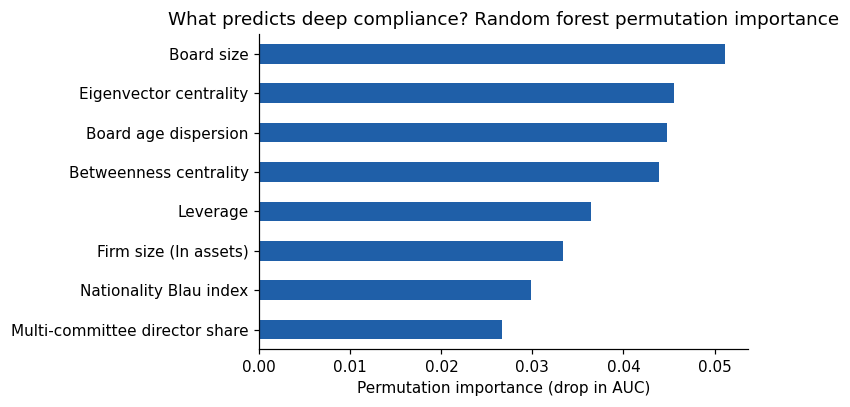

In [18]:
# Random forest classification of deep compliance with 5-fold cross-validation

share_mc = d.groupby("bvd")["multi_comm"].mean().rename("share_multicomm")
d24m = d24.merge(share_mc, on="bvd", how="left")
d24d = pd.get_dummies(d24m, columns=["sector"], prefix="sec")
feats = (["size", "leverage_w", "board_size", "degree", "betweenness", "eigen",
          "n_interlockers", "blau_nat_board", "age_sd_board", "share_multicomm"]
         + [c for c in d24d.columns if c.startswith("sec_")])
X = d24d[feats + ["deep"]].dropna()
y = X.pop("deep")
print("Prediction sample:", X.shape, "| deep-complier share:", f"{y.mean():.1%}")

cvs = StratifiedKFold(5, shuffle=True, random_state=42)
rf = RandomForestClassifier(n_estimators=500, min_samples_leaf=5,
                            random_state=42, class_weight="balanced")
auc_rf = cross_val_score(rf, X, y, cv=cvs, scoring="roc_auc")
auc_lg = cross_val_score(make_pipeline(StandardScaler(),
                         LogisticRegression(max_iter=2000, class_weight="balanced")),
                         X, y, cv=cvs, scoring="roc_auc")
print(f"Random forest CV AUC: {auc_rf.mean():.3f} +/- {auc_rf.std():.3f}")
print(f"Logistic benchmark CV AUC: {auc_lg.mean():.3f} +/- {auc_lg.std():.3f}")

rf.fit(X, y)
pi = permutation_importance(rf, X, y, n_repeats=30, random_state=42,
                            scoring="roc_auc")
LABELS = {"board_size": "Board size", "eigen": "Eigenvector centrality",
          "betweenness": "Betweenness centrality", "degree": "Interlock degree",
          "n_interlockers": "Interlocking directors (n)",
          "age_sd_board": "Board age dispersion",
          "blau_nat_board": "Nationality Blau index",
          "share_multicomm": "Multi-committee director share",
          "leverage_w": "Leverage", "size": "Firm size (ln assets)"}
imp = pd.Series(pi.importances_mean, index=X.columns).sort_values().tail(8)
imp.index = [LABELS.get(i, i) for i in imp.index]
plt.figure(figsize=(7, 3.8))
imp.plot.barh(color="#1f5fa8")
plt.xlabel("Permutation importance (drop in AUC)")
plt.title("What predicts deep compliance? Random forest permutation importance")
plt.tight_layout()
plt.show()


In [19]:
# Random forest regression of ROA on all diversity measures

Xr = d24[["fem_board", "fem_exec", "fem_comm", "fem_inter", "blau_nat_board",
          "blau_nat_exec", "blau_nat_comm", "age_sd_board", "size",
          "leverage_w", "board_size", "degree", "roa_w"]].dropna()
yr_ = Xr.pop("roa_w")
rfr = RandomForestRegressor(n_estimators=500, min_samples_leaf=5, random_state=42)
r2 = cross_val_score(rfr, Xr, yr_, cv=KFold(5, shuffle=True, random_state=42),
                     scoring="r2")
print(f"Cross-validated out-of-sample R2: {r2.mean():.3f} +/- {r2.std():.3f} "
      f"(n={len(Xr)})")
print("A negative out-of-sample R2 means the model predicts ROA worse than "
      "simply using the mean.")


Cross-validated out-of-sample R2: -0.089 +/- 0.098 (n=197)
A negative out-of-sample R2 means the model predicts ROA worse than simply using the mean.


Clustering sample: 222 firms (2024, complete profiles)
  k=2 | Silhouette Score: 0.1697
  k=3 | Silhouette Score: 0.1547
  k=4 | Silhouette Score: 0.1640
  k=5 | Silhouette Score: 0.1344
  k=6 | Silhouette Score: 0.1386

Cluster profiles (raw means):
         fem_board  fem_exec  fem_comm  fem_inter  blau_nat_board  \
cluster                                                             
0            0.338     0.262     0.258      0.220           0.351   
1            0.462     0.259     0.558      0.580           0.581   
2            0.543     0.578     0.671      0.577           0.144   
3            0.403     0.192     0.577      0.711           0.152   

         age_sd_board  
cluster                
0               6.867  
1               6.782  
2               5.900  
3               8.360  

Cluster sizes: {0: 47, 1: 83, 2: 47, 3: 45} | share of deep compliers per cluster: {0: 0.19, 1: 0.39, 2: 0.96, 3: 0.22}


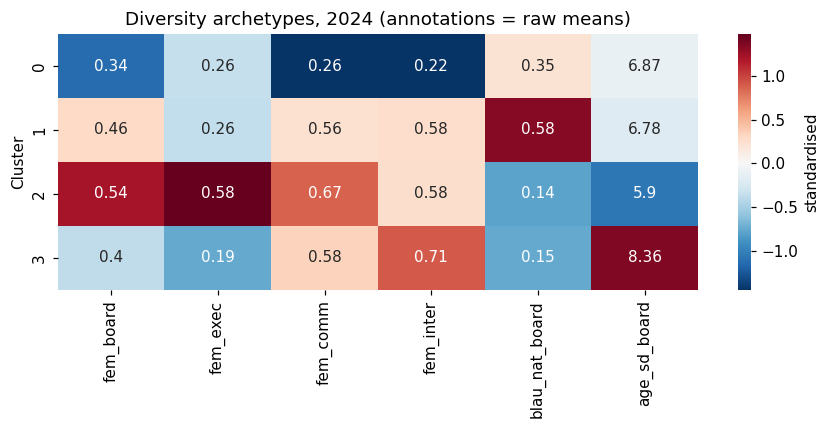

PCA explained variance ratios: [0.304 0.191 0.162 0.143 0.123 0.077]


In [20]:
# K-Means clustering of firm diversity profiles into archetypes

feat = ["fem_board", "fem_exec", "fem_comm", "fem_inter",
        "blau_nat_board", "age_sd_board"]
Xc = d24.dropna(subset=feat)[["bvd"] + feat].copy()
Z = StandardScaler().fit_transform(Xc[feat])
print("Clustering sample:", len(Xc), "firms (2024, complete profiles)")

# Silhouette scores across candidate k values
for k in range(2, 7):
    km_t = KMeans(n_clusters=k, init="k-means++", n_init=20, random_state=42).fit(Z)
    print(f"  k={k} | Silhouette Score: {silhouette_score(Z, km_t.labels_):.4f}")

# k=4 retained; silhouettes uniformly low, so read as a descriptive typology
km = KMeans(n_clusters=4, init="k-means++", n_init=20, random_state=42).fit(Z)
Xc["cluster"] = km.labels_
prof = Xc.groupby("cluster")[feat].mean()
sizes = Xc["cluster"].value_counts().sort_index()
deep_by = Xc.assign(deep=Xc["bvd"].map(d24.set_index("bvd")["deep"])
                    ).groupby("cluster")["deep"].mean()
print("\nCluster profiles (raw means):")
print(prof.round(3))
print("\nCluster sizes:", sizes.to_dict(),
      "| share of deep compliers per cluster:",
      {k: round(v, 2) for k, v in deep_by.items()})

plt.figure(figsize=(8, 4))
sns.heatmap((prof - prof.mean()) / prof.std(), cmap="RdBu_r", center=0,
            annot=prof.round(2), fmt="", cbar_kws={"label": "standardised"})
plt.title("Diversity archetypes, 2024 (annotations = raw means)")
plt.ylabel("Cluster")
plt.tight_layout()
plt.show()

# PCA on the same profile
pca = PCA().fit(Z)
print("PCA explained variance ratios:",
      np.round(pca.explained_variance_ratio_, 3))


### Machine Learning

Deep compliance is only weakly predictable from firm observables: cross-validated AUC 0.610 against a logistic benchmark of 0.632. The absence of a non-linear advantage indicates largely linear, weak relationships; the modest absolute level indicates firm-specific choices rather than size or sector. Permutation importance ranks board size, eigenvector and betweenness centrality, and board age dispersion highest, corroborating Part 6 without functional-form assumptions.

A flexible learner given every diversity measure produces a cross-validated R² of -0.089 for ROA, worse than predicting the mean. This does not prove no relationship exists: with 12 predictors and roughly 157 training rows per fold, a weak true effect would also fail to generalise. It does establish that whatever the Part 4 coefficients capture is too small or unstable to predict out of sample.

Clustering treats diversity as a configuration. Silhouettes are uniformly low (0.13-0.17), so the four-cluster solution is a descriptive typology rather than a claim of natural groups: a uniformly low cluster (n = 47); a broad-but-shallow cluster (n = 83) with the most internationally diverse boards and majority-female interlockers whose executive share averages 26%; a monitoring-concentrated cluster (n = 45); and a deep-diversity cluster (n = 47) where 96% are deep compliers. Shallow compliance is thus two patterns, not one. The first principal component explains only 30.4% of variance across the six dimensions.


## Overall Conclusions

Headline board diversity has risen (37.4% to 42.9%) but thins sharply in the executive layer, where the gap has held at around 12 percentage points. Boards bunch immediately above the 40% line while the sector converges on roughly 45%, so the target acts as a focal point without pulling firms toward parity. Beneath the aggregate, women are channelled into monitoring committees rather than executive roles (0.41 odds ratio), non-UK directors face a parallel filter, and the two penalties compound arithmetically for non-UK women. The interlocking elite is now majority-female, yet diversity profiles do not diffuse through the network; central firms are simply more likely to have implemented diversity deeply. The performance associations vanish level-by-level, under fixed effects, in the critical-mass specification, in the deep-versus-shallow comparison, and out of sample. Configurationally, shallow compliance takes two forms and no single "diversity factor" exists.

All statistics are reproducible end-to-end from the two ORBIS exports; director identities are salted SHA-256 pseudonyms throughout.


## PART 8

### Supplementary Robustness and Report Figures

Supplementary outputs supporting the written report: the busy-director robustness specification, compliance shares by year, report-formatted versions of Figures 4.3, 4.4, 4.6, 4.7 and 4.8, the convergence-equilibrium estimate and the ex-financials sensitivity check. These cells reuse objects defined earlier.


In [21]:
# Busy-director robustness: joint pooled model plus the firm-level share of
# multi-committee directors (reported in Section 4.3)

busy = d.groupby("bvd")["multi_comm"].mean().rename("share_multicomm")
full_b = full.merge(busy, on="bvd", how="left").dropna(subset=["share_multicomm"])
m_busy = cluster_ols("roa_w" + FULL_RHS + " + share_multicomm", full_b,
                     "ROA - all four levels jointly + busy-director share")



ROA - all four levels jointly + busy-director share (n=1059, R2=0.140)
                   coef     se      p
fem_board        14.442  4.630  0.002
fem_exec         -3.519  2.444  0.150
fem_comm         -6.939  2.582  0.007
fem_inter         0.468  2.195  0.831
blau_nat_board   -2.102  2.376  0.376
size             -1.083  0.687  0.115
leverage_w       -8.430  4.321  0.051
board_size        0.146  0.155  0.347
share_multicomm  -1.673  3.489  0.632


In [22]:
# Deep / shallow compliance shares by year (context for Section 4.2)

cs = df.dropna(subset=["fem_board", "fem_exec"]).copy()
by_year = cs.groupby("year").apply(lambda g: pd.Series({
    "meets_40_board": (g["fem_board"] >= .4).mean(),
    "deep": ((g["fem_board"] >= .4) & (g["fem_exec"] >= .3)).mean(),
    "shallow": ((g["fem_board"] >= .4) & (g["fem_exec"] < .3)).mean(),
    "n": len(g)}), include_groups=False)
print("Compliance shares by year (reconstructed panel):")
print(by_year.round(3))


Compliance shares by year (reconstructed panel):
      meets_40_board   deep  shallow      n
year                                       
2019           0.417  0.278    0.139  266.0
2020           0.446  0.295    0.151  285.0
2021           0.493  0.322    0.171  298.0
2022           0.580  0.371    0.208  307.0
2023           0.623  0.403    0.220  313.0
2024           0.644  0.410    0.233  317.0


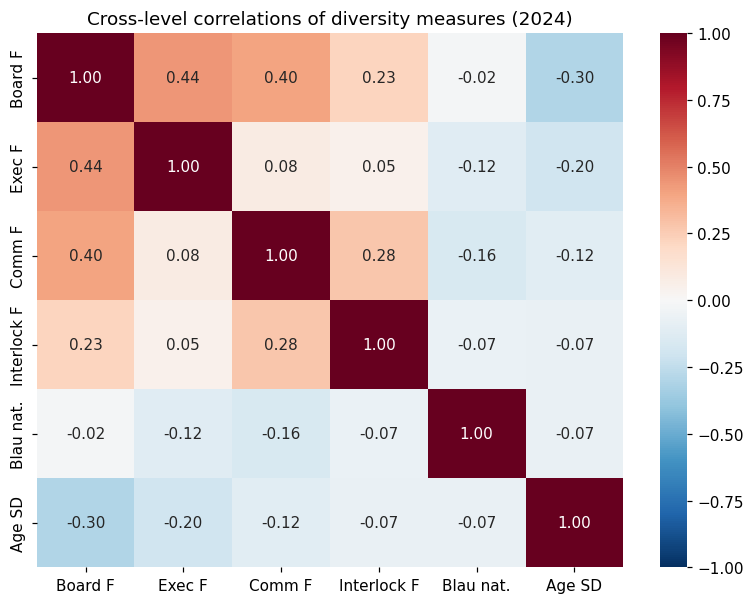

In [23]:
# Report Figure 4.3: cross-level correlations of diversity measures, 2024

cvars = ["fem_board", "fem_exec", "fem_comm", "fem_inter",
         "blau_nat_board", "age_sd_board"]
clabs = ["Board F", "Exec F", "Comm F", "Interlock F", "Blau nat.", "Age SD"]
cm = d24[cvars].corr()
plt.figure(figsize=(7.2, 5.6))
sns.heatmap(cm, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            xticklabels=clabs, yticklabels=clabs)
plt.title("Cross-level correlations of diversity measures (2024)")
plt.tight_layout()
plt.show()


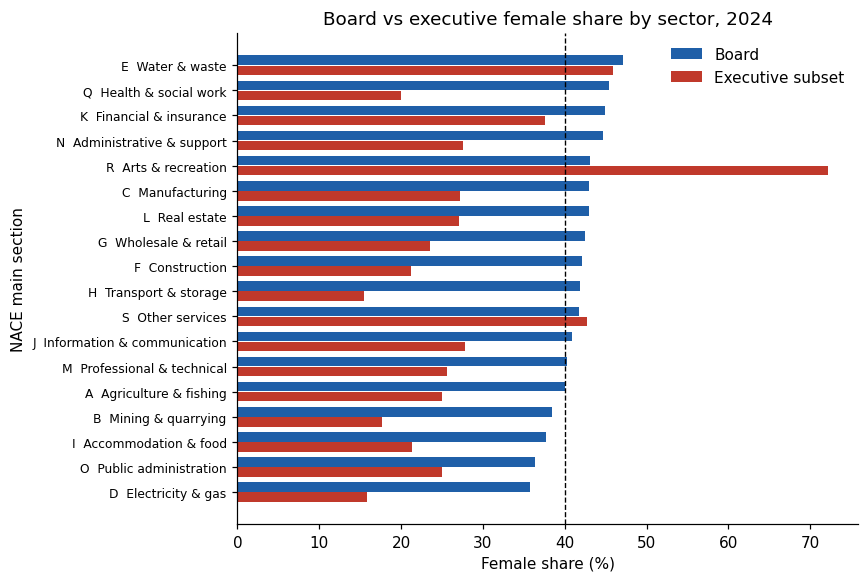

In [24]:
# Report Figure 4.4: board vs executive female share by NACE main section, 2024

sec24 = (d24.groupby("sector")[["fem_board", "fem_exec"]].mean()
         .dropna().sort_values("fem_board"))
yy = np.arange(len(sec24))
plt.figure(figsize=(8, 5.4))
plt.barh(yy + 0.2, sec24["fem_board"] * 100, height=0.38,
         color="#1f5fa8", label="Board")
plt.barh(yy - 0.2, sec24["fem_exec"] * 100, height=0.38,
         color="#c0392b", label="Executive subset")
plt.axvline(40, ls="--", color="k", lw=.9)
NACE = {"A": "A  Agriculture & fishing", "B": "B  Mining & quarrying",
        "C": "C  Manufacturing", "D": "D  Electricity & gas",
        "E": "E  Water & waste", "F": "F  Construction",
        "G": "G  Wholesale & retail", "H": "H  Transport & storage",
        "I": "I  Accommodation & food", "J": "J  Information & communication",
        "K": "K  Financial & insurance", "L": "L  Real estate",
        "M": "M  Professional & technical", "N": "N  Administrative & support",
        "O": "O  Public administration", "P": "P  Education",
        "Q": "Q  Health & social work", "R": "R  Arts & recreation",
        "S": "S  Other services"}
plt.yticks(yy, [NACE.get(s, s) for s in sec24.index], fontsize=8)
plt.xlabel("Female share (%)")
plt.ylabel("NACE main section")
plt.title("Board vs executive female share by sector, 2024")
plt.legend(frameon=False)
plt.tight_layout()
plt.show()


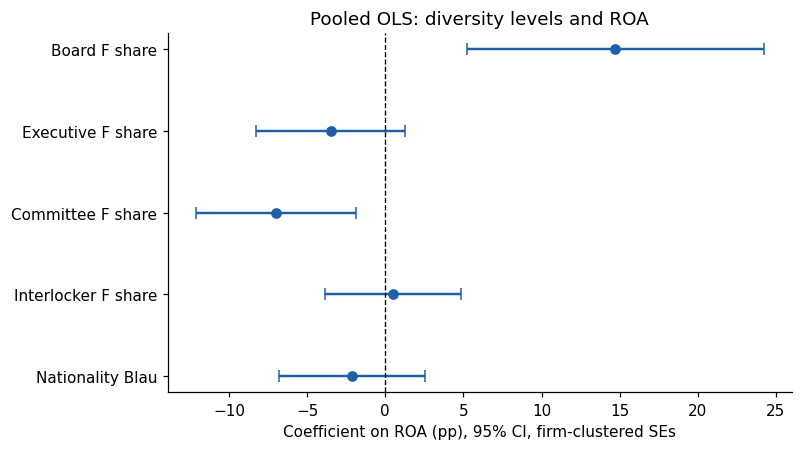

In [25]:
# Report Figure 4.6: pooled OLS coefficients on ROA with 95% confidence intervals

terms = ["fem_board", "fem_exec", "fem_comm", "fem_inter", "blau_nat_board"]
tlabs = ["Board F share", "Executive F share", "Committee F share",
         "Interlocker F share", "Nationality Blau"]
ci = m_roa.conf_int().loc[terms]
est_ = m_roa.params[terms]
ypos = np.arange(len(terms))[::-1]
plt.figure(figsize=(7.4, 4.2))
plt.errorbar(est_, ypos, xerr=[est_ - ci[0], ci[1] - est_],
             fmt="o", color="#1f5fa8", capsize=4, lw=1.6)
plt.axvline(0, ls="--", color="k", lw=.9)
plt.yticks(ypos, tlabs)
plt.xlabel("Coefficient on ROA (pp), 95% CI, firm-clustered SEs")
plt.title("Pooled OLS: diversity levels and ROA")
plt.tight_layout()
plt.show()


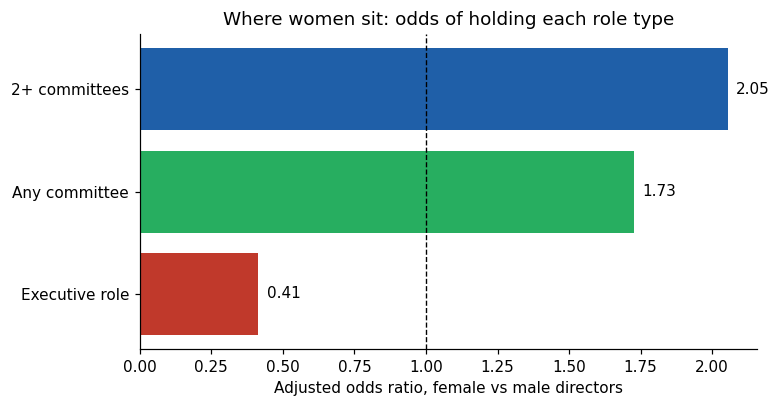

In [26]:
# Report Figure 4.7: adjusted odds ratios for female directors across role types

or_specs = [("exec01", "", "Executive role", "#c0392b"),
            ("any_comm", " + exec01", "Any committee", "#27ae60"),
            ("multi_comm", "", "2+ committees", "#1f5fa8")]
labels_, ors_, cols_ = [], [], []
for dv, extra, label, col in or_specs:
    m_ = smf.logit(f"{dv} ~ female + nonuk + age_c + bsize{extra}",
                   data=d.dropna(subset=["age_c"])).fit(disp=0)
    labels_.append(label); ors_.append(np.exp(m_.params["female"])); cols_.append(col)
plt.figure(figsize=(7.2, 3.8))
plt.barh(labels_, ors_, color=cols_)
plt.axvline(1, ls="--", color="k", lw=.9)
for i, v in enumerate(ors_):
    plt.text(v + 0.03, i, f"{v:.2f}", va="center")
plt.xlabel("Adjusted odds ratio, female vs male directors")
plt.title("Where women sit: odds of holding each role type")
plt.tight_layout()
plt.show()


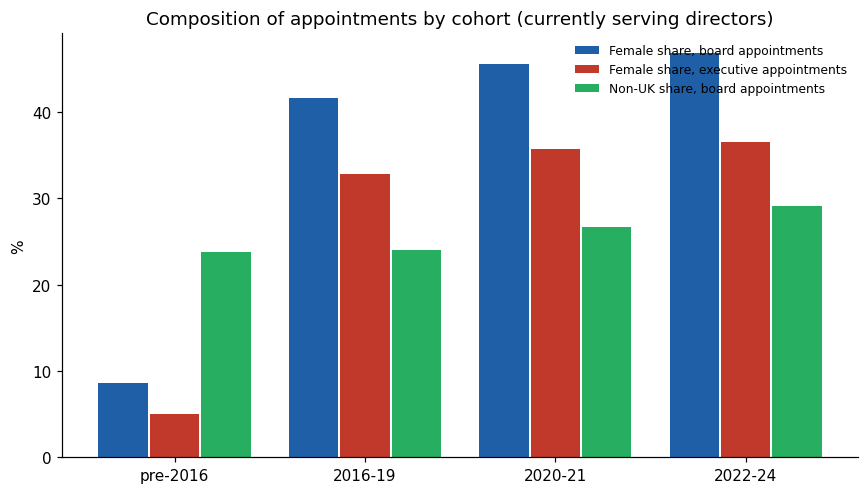

          fem_all  nonuk  fem_exec_appt
cohort                                 
pre-2016    0.086  0.238          0.050
2016-19     0.417  0.240          0.329
2020-21     0.456  0.267          0.357
2022-24     0.468  0.291          0.365


In [27]:
# Report Figure 4.8: composition of appointments by cohort (currently serving)

coh = d2.groupby("cohort").agg(fem_all=("female", "mean"),
                               nonuk=("nonuk", "mean"))
coh["fem_exec_appt"] = d2[d2["exec01"] == 1].groupby("cohort")["female"].mean()
xx = np.arange(len(coh))
plt.figure(figsize=(8, 4.6))
plt.bar(xx - 0.27, coh["fem_all"] * 100, width=0.26,
        color="#1f5fa8", label="Female share, board appointments")
plt.bar(xx, coh["fem_exec_appt"] * 100, width=0.26,
        color="#c0392b", label="Female share, executive appointments")
plt.bar(xx + 0.27, coh["nonuk"] * 100, width=0.26,
        color="#27ae60", label="Non-UK share, board appointments")
plt.xticks(xx, coh.index)
plt.ylabel("%")
plt.title("Composition of appointments by cohort (currently serving directors)")
plt.legend(frameon=False, fontsize=8)
plt.tight_layout()
plt.show()
print(coh.round(3))


In [28]:
# Convergence equilibrium and corridor stability (Section 4.2)
# Implied steady state with a bootstrap CI, plus mean change by starting band

cv = df.pivot_table(index="bvd", columns="year", values="fem_board")[[2021, 2024]].dropna()
cv.columns = ["y21", "y24"]
cv["chg"] = (cv["y24"] - cv["y21"]) * 100
cv["y21p"] = cv["y21"] * 100
m_cv = smf.ols("chg ~ y21p", data=cv).fit(cov_type="HC1")
a_, b_ = m_cv.params["Intercept"], m_cv.params["y21p"]
print(f"slope {b_:.3f} (p={m_cv.pvalues['y21p']:.4f}), implied convergence point "
      f"{-a_/b_:.1f}% female (n={len(cv)})")
rng = np.random.default_rng(42)
eqs = []
for _ in range(2000):
    s = cv.iloc[rng.integers(0, len(cv), len(cv))]
    ms = smf.ols("chg ~ y21p", data=s).fit()
    eqs.append(-ms.params["Intercept"] / ms.params["y21p"])
print(f"bootstrap 95% CI for convergence point: "
      f"[{np.percentile(eqs, 2.5):.1f}, {np.percentile(eqs, 97.5):.1f}]")
for lab, msk in [("below 40% in 2021", cv.y21p < 40),
                 ("40-50% band", (cv.y21p >= 40) & (cv.y21p <= 50)),
                 ("above 50% in 2021", cv.y21p > 50)]:
    print(f"mean change, {lab}: {cv.loc[msk,'chg'].mean():+.1f}pp (n={msk.sum()})")


slope -0.580 (p=0.0000), implied convergence point 45.3% female (n=339)
bootstrap 95% CI for convergence point: [43.6, 47.0]
mean change, below 40% in 2021: +10.7pp (n=159)
mean change, 40-50% band: +0.3pp (n=120)
mean change, above 50% in 2021: -13.1pp (n=60)


bootstrap 95% CI for convergence point: [43.6, 47.0]
mean change, below 40% in 2021: +10.7pp (n=159)
mean change, 40-50% band: +0.3pp (n=120)
mean change, above 50% in 2021: -13.1pp (n=60)


In [29]:
# Sensitivity: performance models excluding the financial sector (Section 4.3)
# NACE K is a third of the sample and ROA is least comparable there.

fk = full[full["sector"] != "K"]
m_exfin = cluster_ols("roa_w" + FULL_RHS, fk, "ROA - all four levels, ex-financials")
d24nf = d24[d24["sector"] != "K"].dropna(subset=["fem_board", "fem_exec", "roa_w"])
deep_nf = d24nf[(d24nf.fem_board >= .4) & (d24nf.fem_exec >= .3)]["roa_w"]
shal_nf = d24nf[(d24nf.fem_board >= .4) & (d24nf.fem_exec < .3)]["roa_w"]
t_, p_ = stats.ttest_ind(deep_nf, shal_nf, equal_var=False)
print(f"\nDeep (n={len(deep_nf)}, mean {deep_nf.mean():.2f}) vs shallow "
      f"(n={len(shal_nf)}, mean {shal_nf.mean():.2f}) ex-financials: t={t_:.2f}, p={p_:.3f}")



ROA - all four levels, ex-financials (n=844, R2=0.151)
                  coef     se      p
fem_board       13.885  5.755  0.016
fem_exec        -1.699  2.856  0.552
fem_comm        -6.217  3.467  0.073
fem_inter        1.709  2.538  0.501
blau_nat_board  -2.604  2.477  0.293
size            -0.960  0.720  0.183
leverage_w      -7.704  4.756  0.105
board_size       0.144  0.245  0.555

Deep (n=73, mean 6.85) vs shallow (n=56, mean 6.72) ex-financials: t=0.08, p=0.937


### Supplementary Analysis

The busy-director specification leaves the joint pooled model essentially unchanged (board share +14.44, p = 0.002; committee share -6.94, p = 0.007; busy-director share -1.67, p = 0.632). Compliance shares by year show depth improving alongside the headline: deep compliers rise from 27.8% in 2019 to 41.0% in 2024, shallow compliance from 13.9% to 23.3%. The convergence equilibrium implies a steady state near 45% female (bootstrap 95% CI 43.6 to 47.0). The ex-financials estimates confirm that neither the suppression pattern nor the deep/shallow null is an artefact of the financial sector's weight in the index.
